Pre-Requisites:

- pystan
- prophet

In [1]:
pip install pystan

INFO: pip is looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
     --- ------------------------------------ 1.3/16.2 MB 11.0 MB/s eta 0:00:02
     ------------ --------------------------- 5.2/16.2 MB 16.4 MB/s eta 0:00:01
     ----------------------- ---------------- 9.7/16.2 MB 18.2 MB/s eta 0:00:01
     ---------------------------------- ---- 14.4/16.2 MB 19.5 MB/s eta 0:00:01
     ---------------------------------------- 16.2/16.2 MB 18.4 MB/s  0:00

  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [23 lines of output]
  Traceback (most recent call last):
    File "C:\Users\Dell\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
      main()
      ~~~~^^
    File "C:\Users\Dell\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
      json_out["return_val"] = hook(**hook_input["kwargs"])
                               ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\Dell\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
      return hook(config_settings)
    File "C:\Users\Dell\AppData\Local\Temp\pip-build-env-4rxes79n\overlay\Lib\site-packages\setuptools\build_meta.py", line 333, in get_requires_for_build_wheel
      return self._get_build_requires(config_settings, requirement

In [2]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 1.8 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/12.1 MB 2.1 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/12.1 MB 2.2 MB/s eta 0:00:05
   ------ --------------------------------- 2.1/12.1 MB 2.3 MB/s eta 0:00:05
   -------- ------------------------------- 2.6/12.1 MB 2.4 MB/s eta 0:00:05
   ---------- ----------------------------- 3.1/12.1 MB 2.4 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/12.1 MB 2.5 MB/s eta 0:00:04
   -------------- ------------------------- 4.5/12.1 MB 2.5 MB/s eta 0:00:04
   ---------------- ----------------------- 5.0/12.1 MB 2.6 MB/s eta 0:00:03
   ------------------ --------------------- 5.5/12.1 MB 2.6 MB/s eta 0:00:03
   -------------------- ------------------- 6.3/12.1 MB 2.6 MB/s eta 0:00:03
   ----------

In [3]:
from prophet import Prophet
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

In [23]:
# Mounting the google colab drive
# from google.colab import drive
# drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [4]:
df = pd.read_csv('AirPassengers.csv')
df.head(5)
df = df.rename(columns={'#Passengers': 'y', 'Month':'ds'})

In [5]:
df.tail(5)

,ds,y
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [6]:
df['y_orig'] = df['y']
print(df.head(5))

        ds    y  y_orig
0  1949-01  112     112
1  1949-02  118     118
2  1949-03  132     132
3  1949-04  129     129
4  1949-05  121     121


In [7]:
# to save a copy of the original data..you'll see why shortly.
df['y'] = np.log(df['y'])

In [9]:
df.head(5)

,ds,y,y_orig
0,1949-01,4.718499,112
1,1949-02,4.770685,118
2,1949-03,4.882802,132
3,1949-04,4.859812,129
4,1949-05,4.795791,121


In [10]:
model = Prophet() #instantiate Prophet
model.add_country_holidays(country_name='US')
model.fit(df)

#train_test_split: df: train/test, then run the code for train, compare the prediction vs test

22:55:08 - cmdstanpy - INFO - Chain [1] start processing
22:55:10 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
'''     'year': 'A',
        'quarter': 'Q',
        'month': 'M',
        'day': 'D',
        'hour': 'H',
        'minute': 'T',
        'second': 'S',
        'millisecond': 'L',
        'microsecond': 'U',
        'nanosecond': 'N'}
'''
#future_data = model.make_future_dataframe(periods=6, freq = 'H')
future_data = model.make_future_dataframe(periods=12, freq = 'M')

C:\Users\Dell\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [12]:
forecast_data = model.predict(future_data)

In [13]:
forecast_data.tail(5)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Armistice Day,Armistice Day_lower,Armistice Day_upper,Christmas Day,...,holidays,holidays_lower,holidays_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
151,1961-07-31,6.274610,6.434736,6.532428,6.261375,6.286573,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.209377,0.209377,0.209377,0.0,0.0,0.0,6.483987
152,1961-08-31,6.283633,6.312277,6.409617,6.267369,6.298625,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.077400,0.077400,0.077400,0.0,0.0,0.0,6.361033
153,1961-09-30,6.292364,6.155151,6.256049,6.272710,6.310760,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.087349,-0.087349,-0.087349,0.0,0.0,0.0,6.205015
154,1961-10-31,6.301386,6.022564,6.122828,6.278682,6.322136,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.231086,-0.231086,-0.231086,0.0,0.0,0.0,6.070300
155,1961-11-30,6.310117,6.160611,6.264166,6.283615,6.334031,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.099021,-0.099021,-0.099021,0.0,0.0,0.0,6.211095


In [14]:

forecast_data[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5)

,ds,yhat,yhat_lower,yhat_upper
151,1961-07-31,6.483987,6.434736,6.532428
152,1961-08-31,6.361033,6.312277,6.409617
153,1961-09-30,6.205015,6.155151,6.256049
154,1961-10-31,6.070300,6.022564,6.122828
155,1961-11-30,6.211095,6.160611,6.264166


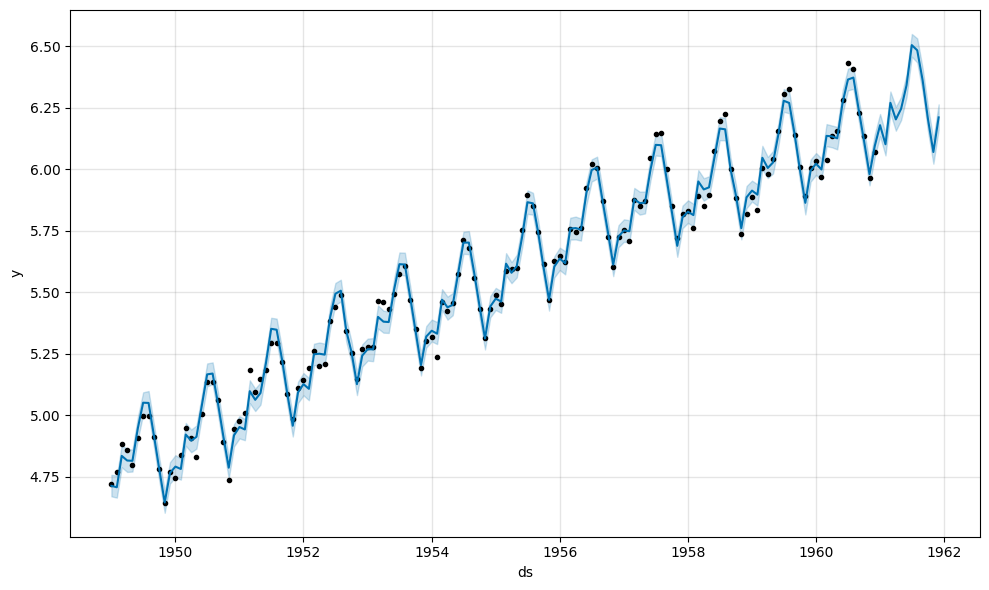

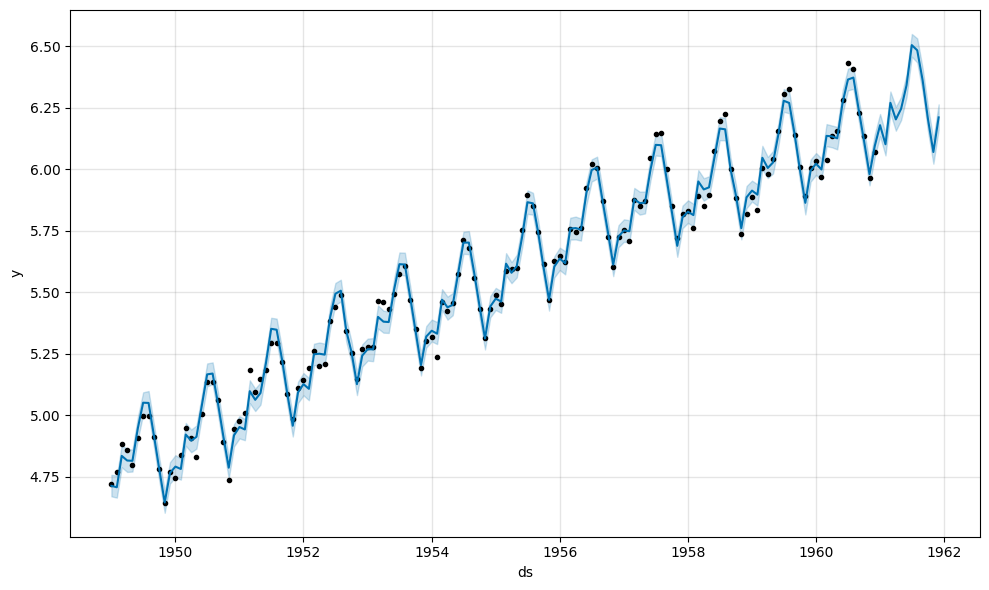

In [15]:
model.plot(forecast_data)

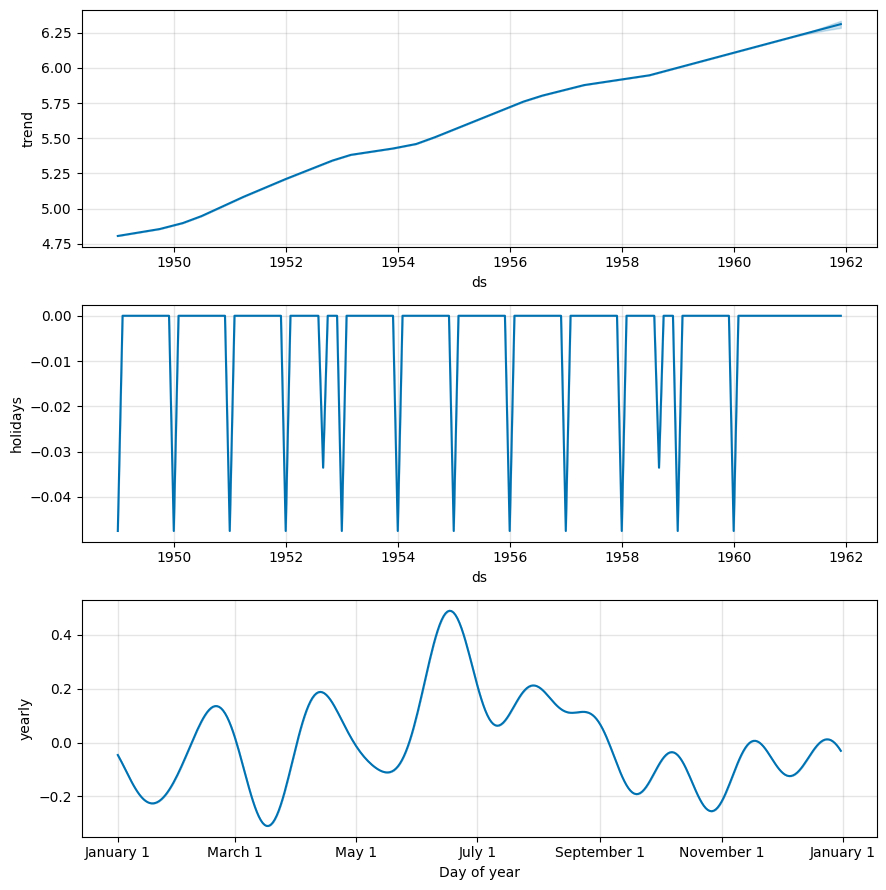

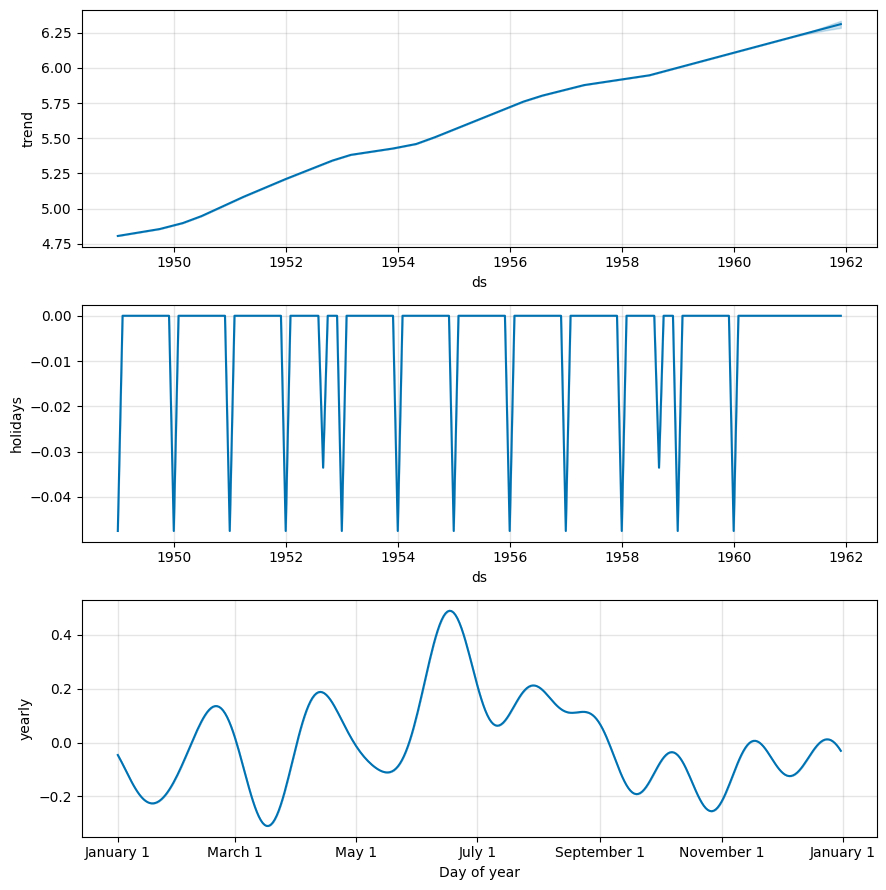

In [16]:
model.plot_components(forecast_data)

In [17]:
forecast_data_orig = forecast_data # make sure we save the original forecast data
forecast_data_orig['yhat'] = np.exp(forecast_data_orig['yhat'])
forecast_data_orig['yhat_lower'] = np.exp(forecast_data_orig['yhat_lower'])
forecast_data_orig['yhat_upper'] = np.exp(forecast_data_orig['yhat_upper'])

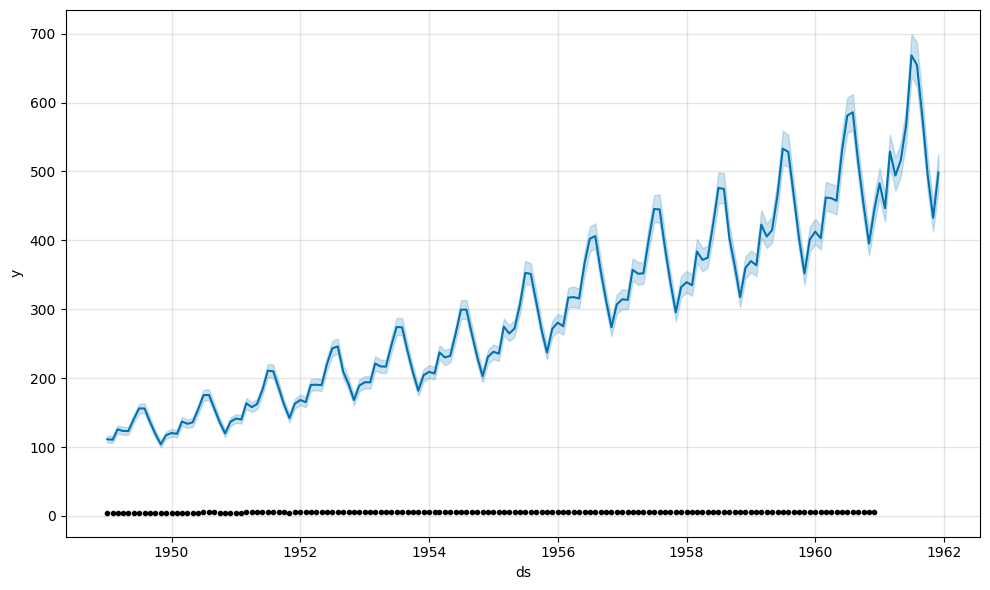

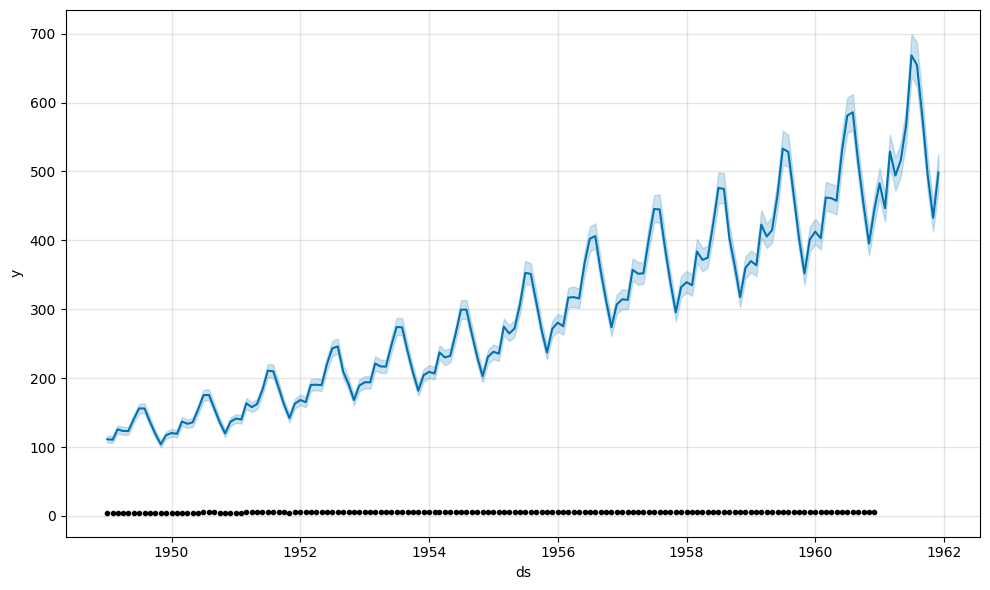

In [18]:
model.plot(forecast_data_orig)

In [19]:
df['y_log']=df['y'] #copy the log-transformed data to another column
df['y']=df['y_orig']

In [20]:
final_df = pd.DataFrame(forecast_data_orig)

In [21]:
import plotly.graph_objs as go
import plotly.offline as py

In [22]:
#Plot predicted and actual line graph with X=dates, Y=Outbound
actual_chart = go.Scatter(y=df["y_orig"], name= 'Actual')
predict_chart = go.Scatter(y=final_df["yhat"], name= 'Predicted')
predict_chart_upper = go.Scatter(y=final_df["yhat_upper"], name= 'Predicted Upper')
predict_chart_lower = go.Scatter(y=final_df["yhat_lower"], name= 'Predicted Lower')
py.plot([actual_chart, predict_chart, predict_chart_upper, predict_chart_lower], image_width=400, image_height=400)
#py.plot([actual_chart, predict_chart, predict_chart_upper, predict_chart_lower], filename = 'templates/' +'filename.html', auto_open=False)

'temp-plot.html'

In [ ]:
fig = model.plot(forecast_data)
fig.savefig('forecast.png')